# 04 — Avaliação e Explicabilidade (SHAP)

**Objetivo:** Calcular métricas finais (acurácia, F1, ROC-AUC, matriz de confusão)
e usar SHAP para explicar as predições do modelo selecionado.

In [1]:
import sys
sys.path.append('..')

import joblib
import pandas as pd
from pathlib import Path

from src.data_loader import load_breast_cancer_data
from src.preprocessing import split_and_scale
from src.evaluate import evaluate_all_models

df = load_breast_cancer_data()
X_train, X_test, y_train, y_test, scaler = split_and_scale(df)

models_dir = Path("../outputs/models")
modelos_treinados = {
    "logistic_regression": joblib.load(models_dir / "logistic_regression.pkl"),
    "random_forest": joblib.load(models_dir / "random_forest.pkl"),
    "knn": joblib.load(models_dir / "knn.pkl"),
}

print("Modelos carregados:", list(modelos_treinados.keys()))

Modelos carregados: ['logistic_regression', 'random_forest', 'knn']


In [2]:
resultados = evaluate_all_models(modelos_treinados, X_test, y_test)
resultados

,accuracy,precision,recall,f1_score
modelo,,,,
logistic_regression,0.964912,0.975000,0.928571,0.951220
random_forest,0.973684,1.000000,0.928571,0.962963
knn,0.956140,0.974359,0.904762,0.938272


In [3]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from src.models import get_model

X = df.drop(columns=['diagnosis'])
y = (df['diagnosis'] == 'M').astype(int)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

resultados_cv = {}
for nome in ["logistic_regression", "random_forest", "knn"]:
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("modelo", get_model(nome))
    ])
    scores = cross_val_score(pipeline, X, y, cv=cv, scoring="recall")
    resultados_cv[nome] = scores
    print(f"{nome:20s} | Recall médio: {scores.mean():.3f} (+/- {scores.std():.3f}) | folds: {[round(s,3) for s in scores]}")

logistic_regression  | Recall médio: 0.944 (+/- 0.052) | folds: [np.float64(0.977), np.float64(0.86), np.float64(0.905), np.float64(1.0), np.float64(0.976)]
random_forest        | Recall médio: 0.934 (+/- 0.054) | folds: [np.float64(0.977), np.float64(0.86), np.float64(0.881), np.float64(1.0), np.float64(0.952)]
knn                  | Recall médio: 0.925 (+/- 0.046) | folds: [np.float64(0.953), np.float64(0.884), np.float64(0.881), np.float64(1.0), np.float64(0.905)]


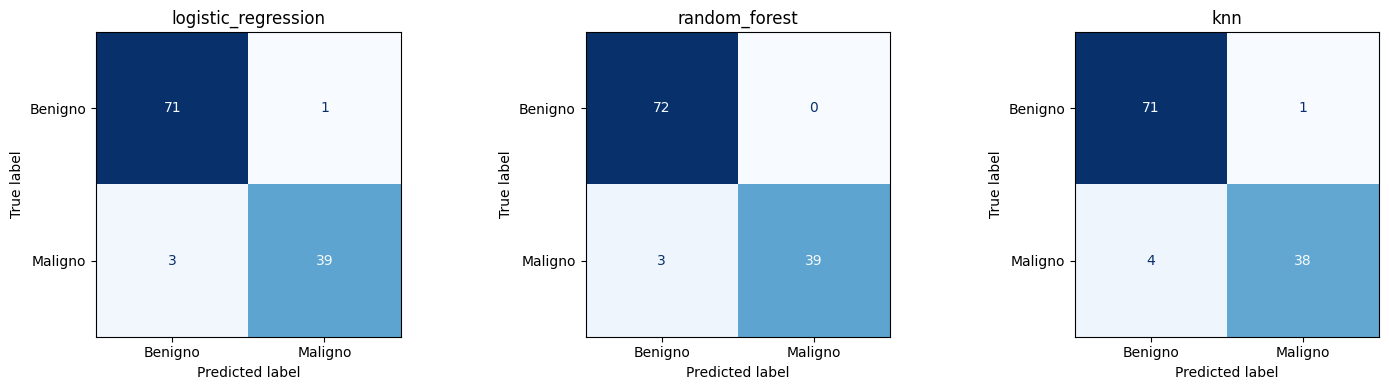

In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (nome, modelo) in zip(axes, modelos_treinados.items()):
    ConfusionMatrixDisplay.from_estimator(
        modelo, X_test, y_test,
        display_labels=["Benigno", "Maligno"],
        cmap="Blues", ax=ax, colorbar=False
    )
    ax.set_title(nome)

plt.tight_layout()
plt.show()